# **Analyze Xenium data**


## **Installations**

In [ ]:
!pip install spatialdata spatialdata-io


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 5.1 MB/s eta 

In [ ]:
!pip install xenium-sdk scanpy squidpy seaborn matplotlib


ERROR: Could not find a version that satisfies the requirement xenium-sdk (from versions: none)
ERROR: No matching distribution found for xenium-sdk


In [ ]:
!pip install squidpy


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.5 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=6ccb571177373ad7ef4198c1ee9f157df6cdf8de159f4699632b429d23397f59
  Stored in directory: /root/.cache/pip/wheels/d6/19/ee/0a6a1793d91c449563b49ccab57ce52da3e6fab7614836bd8c
Successfully built docrep
  Attempting uninstall: imagecodecs
    Found existing installation: imagecodecs 2026.3.6
    Uninstalling imagecodecs-2026.3.6:
      Successfully uninstalled imagecodecs-2026.3.6


In [ ]:
import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

In [ ]:
xenium_path = "./Xenium"
zarr_path = "./Xenium.zarr"

In [ ]:
import os
print(os.getcwd())
print(os.listdir("."))


/content
['.config', 'sample_data']


In [ ]:
from spatialdata_io import xenium


In [ ]:
pip install spatialdata-io


In [ ]:
import spatialdata_io
print(spatialdata_io.__version__)


0.6.0


In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
import os
print(os.listdir("/content"))


['.config', 'sample_data']


# **Download and Load Dataset**

In [ ]:
!wget https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Lung_2fov/Xenium_V1_human_Lung_2fov_outs.zip


--2026-04-26 10:00:40--  https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Lung_2fov/Xenium_V1_human_Lung_2fov_outs.zip
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:1ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 277997802 (265M) [application/zip]
Saving to: ‘Xenium_V1_human_Lung_2fov_outs.zip’

Xenium_V1_human_Lun 100%[===================>] 265.12M  19.9MB/s    in 6.9s    

2026-04-26 10:00:48 (38.2 MB/s) - ‘Xenium_V1_human_Lung_2fov_outs.zip’ saved [277997802/277997802]



In [ ]:
import zipfile

with zipfile.ZipFile("Xenium_V1_human_Lung_2fov_outs.zip", "r") as z:
    z.extractall("/content")


In [ ]:
import os
print(os.listdir("/content"))



['.config', 'transcripts.parquet', 'analysis.zarr.zip', 'nucleus_boundaries.parquet', 'cell_feature_matrix.zarr.zip', 'experiment.xenium', 'analysis.tar.gz', 'gene_panel.json', 'nucleus_boundaries.csv.gz', 'cell_feature_matrix.tar.gz', 'transcripts.zarr.zip', 'cells.zarr.zip', 'morphology_focus', 'cells.parquet', 'Xenium_V1_human_Lung_2fov_outs.zip', 'cell_feature_matrix.h5', 'metrics_summary.csv', 'cells.csv.gz', 'aux_outputs.tar.gz', 'cell_boundaries.csv.gz', 'morphology.ome.tif', 'analysis_summary.html', 'cell_boundaries.parquet', 'transcripts.csv.gz', 'sample_data']


In [ ]:
xenium_path = "/content/Xenium_V1_human_Lung_2fov_outs"


In [ ]:
xenium_path = "/content"


In [ ]:
xenium_path = "./Xenium"
zarr_path = "./Xenium.zarr"

In [ ]:
from spatialdata_io import xenium

sdata = xenium(xenium_path)


/tmp/ipykernel_3453/1443332914.py:3: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = xenium(xenium_path)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


In [ ]:
sdata = xenium(xenium_path)

/tmp/ipykernel_3453/1221898808.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = xenium(xenium_path)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              


In [ ]:
adata = sdata.tables["table"]
adata

AnnData object with n_obs × n_vars = 11898 × 289
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [ ]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
0,aaafiiei-1,67,0,0,0,0,67,139.126411,29.125782,cell_circles,5.0,1.0,1
1,aaanbaof-1,69,0,0,0,0,69,154.434381,31.519064,cell_circles,5.0,1.0,2
2,aabdiein-1,63,0,0,0,0,63,148.247974,25.693907,cell_circles,5.0,1.0,3
3,aabfemmf-1,78,0,0,0,0,78,120.251098,33.551095,cell_circles,5.0,1.0,4
4,aacflbgf-1,19,0,0,0,0,19,31.067501,8.128125,cell_circles,5.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11893,oigahkgf-1,52,0,0,0,0,52,32.918907,21.268595,cell_circles,5.0,1.0,11894
11894,oigeilci-1,38,0,0,0,0,38,33.415626,21.313751,cell_circles,5.0,1.0,11895
11895,oigjdpec-1,30,0,0,0,0,30,27.319532,16.752969,cell_circles,5.0,1.0,11896
11896,oigkmfoa-1,49,0,0,0,0,49,32.196407,16.030469,cell_circles,5.0,1.0,11897


In [ ]:
adata.obsm["spatial"]

array([[ 37.24629974, 667.76745605],
       [ 44.10276031, 701.72283936],
       [ 40.73135757, 684.13360596],
       ...,
       [683.22277832, 359.48660278],
       [685.75463867, 364.47491455],
       [679.56671143, 362.38049316]])

# **Calculate quality control metrics**

In [ ]:
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.002461238905623794
Negative decoding count % : 0.005332684295518221


<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

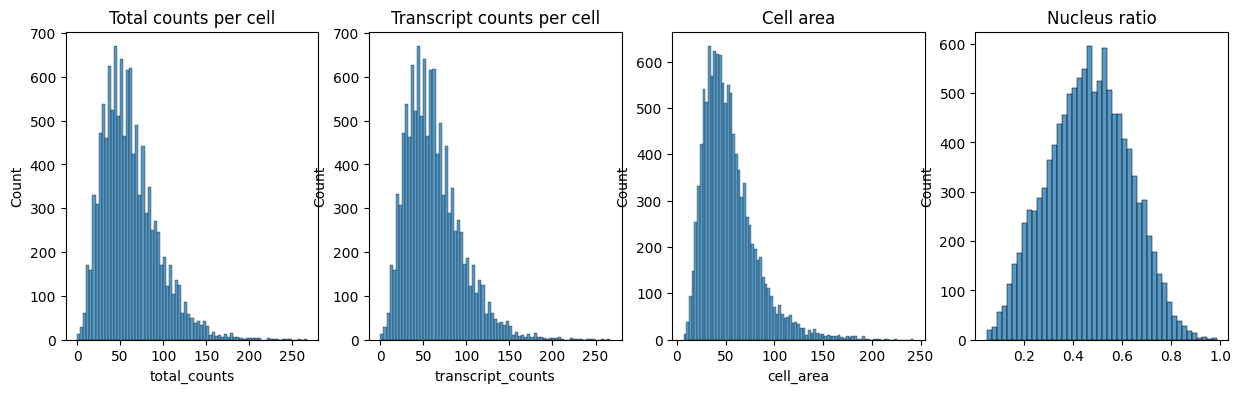

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total counts per cell")
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])

axs[1].set_title("Transcript counts per cell")
sns.histplot(adata.obs["transcript_counts"], kde=False, ax=axs[1])

axs[2].set_title("Cell area")
sns.histplot(adata.obs["cell_area"], kde=False, ax=axs[2])

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)


Filter the cells based on the minimum number of counts required using scanpy.pp.filter_cells. Filter the genes based on the minimum number of cells required with scanpy.pp.filter_genes. The parameters for the both were specified based on the plots above. They were set to filter out the cells and genes with minimum counts and minimum cells respectively.

In [ ]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)


In [ ]:
pip install leidenalg igraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 35.1 MB/s eta 0:00:00


In [ ]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

/tmp/ipykernel_3453/4193936636.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


**Visualize annotation on UMAP and spatial coordinates**
Subplot with scatter plot in UMAP (Uniform Manifold Approximation and Projection) basis. The embedded points were colored, respectively, according to the total counts, number of genes by counts, and leiden clusters in each of the subplots. This gives us some idea of what the data looks like.

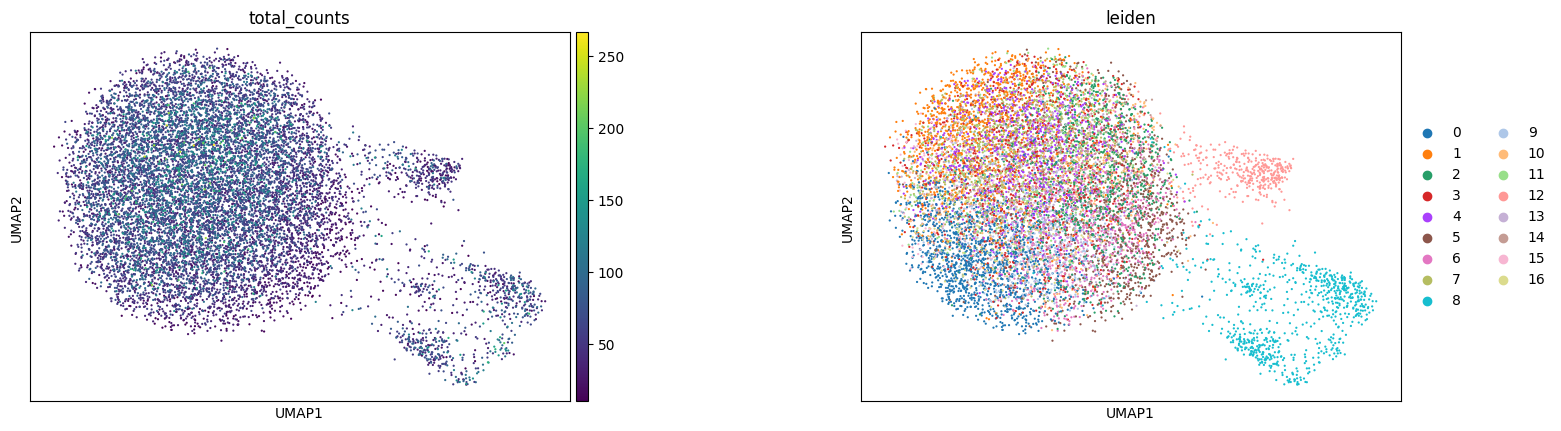

In [ ]:
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "leiden",
    ],
    wspace=0.4,
)


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


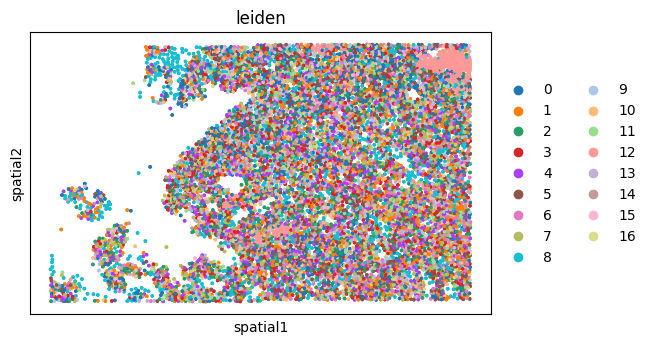

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

# **Computation of spatial statistics**
This example shows how to compute centrality scores, given a spatial graph and cell type annotation.

The scores calculated are closeness centrality, degree centrality and clustering coefficient with the following properties:

closeness centrality - measure of how close the group is to other nodes.

clustering coefficient - measure of the degree to which nodes cluster together.

degree centrality - fraction of non-group members connected to group members.

All scores are descriptive statistics of the spatial graph.

This dataset contains Leiden cluster groups’ annotations in adata.obs, which are used for calculation of centrality scores.

**Building a spatial neighborhood graph**
First, we need to compute a connectivity matrix from spatial coordinates to calculate the centrality scores. We can use squidpy.gr.spatial_neighbors for this purpose. We use the coord_type="generic" based on the data and the neighbors are classified with Delaunay triangulation by specifying delaunay=True.

In [ ]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


In [ ]:
sq.gr.centrality_scores(adata, cluster_key="leiden")

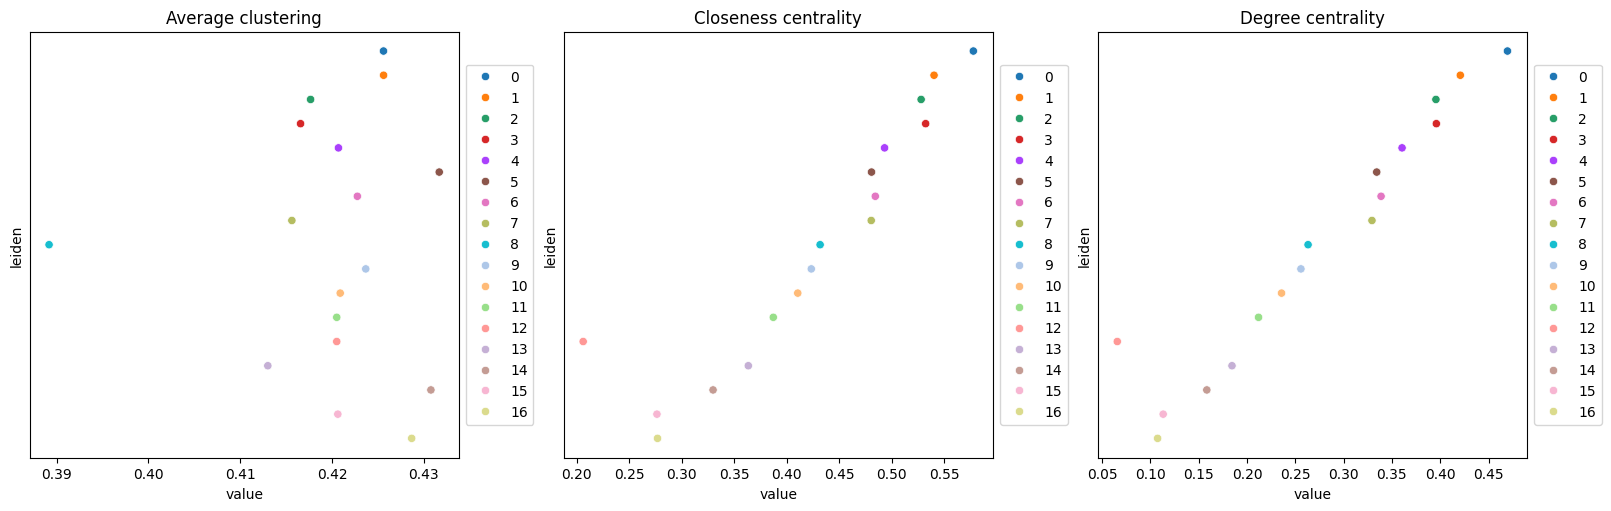

In [ ]:
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

# **Compute co-occurrence probability**
This example shows how to compute the co-occurrence probability.

The co-occurrence score is defined as:

𝑝⁡(𝑒⁢𝑥⁢𝑝|𝑐⁢𝑜⁢𝑛⁢𝑑)
𝑝⁡(𝑒⁢𝑥⁢𝑝)


where 𝑝⁡(𝑒⁢𝑥⁢𝑝|𝑐⁢𝑜⁢𝑛⁢𝑑) is the conditional probability of observing a cluster 𝑒𝑥𝑝 conditioned on the presence of a cluster 𝑐⁢𝑜⁢𝑛⁢𝑑, whereas 𝑝⁡(𝑒⁢𝑥⁢𝑝) is the probability of observing 𝑒𝑥𝑝 in the radius size of interest. The score is computed across increasing radii size around each cell in the tissue.

We can compute the co-occurrence score with squidpy.gr.co_occurrence. Results of co-occurrence probability ratio can be visualized with squidpy.pl.co_occurrence. The ‘3’ in the
𝑝⁡(𝑒⁢𝑥⁢𝑝|𝑐⁢𝑜⁢𝑛⁢𝑑)
𝑝⁡(𝑒⁢𝑥⁢𝑝)

 represents a Leiden clustered group.



In [ ]:
sdata.tables["subsample"] = sc.pp.subsample(adata, fraction=0.5, copy=True)

In [ ]:
adata_subsample = sdata.tables["subsample"]

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


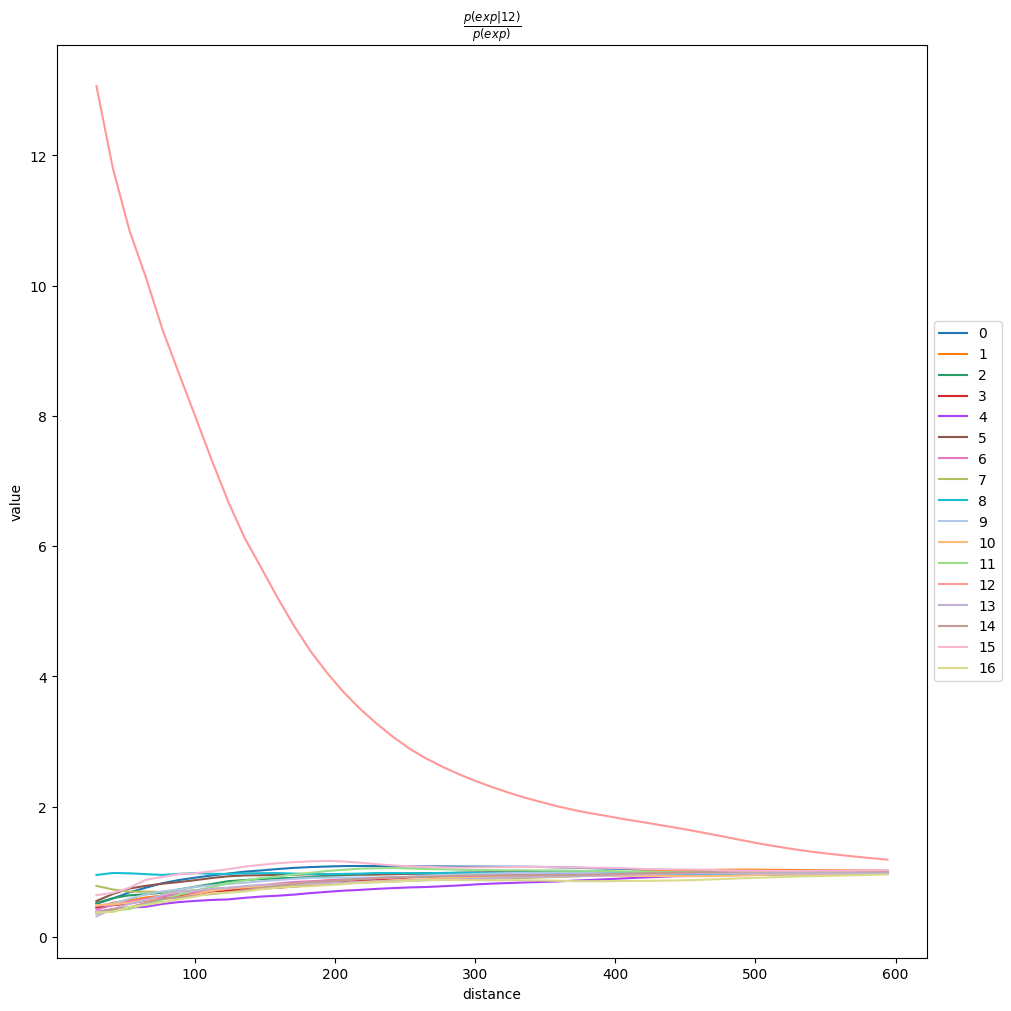

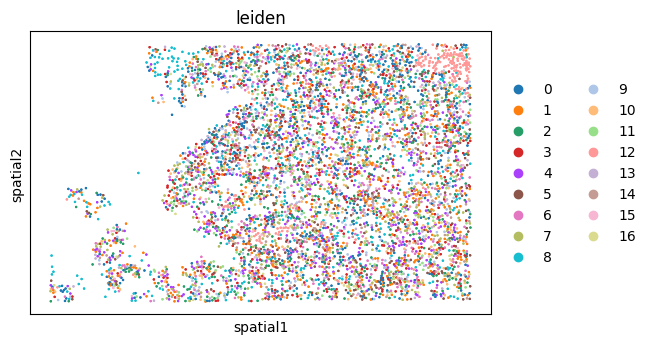

In [ ]:
sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters="12",
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=2,
)

# **Neighbors enrichment analysis**
This example shows how to run the neighbors enrichment analysis routine.

It calculates an enrichment score based on proximity on the connectivity graph of cell clusters. The number of observed events is compared against permutations and a z-score is computed.

This dataset contains cell type annotations in adata.obs which are used for calculation of the neighborhood enrichment. We calculate the neighborhood enrichment score with squidpy.gr.nhood_enrichment.

In [ ]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

  0%|          | 0/1000 [00:00<?, ?/s]

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


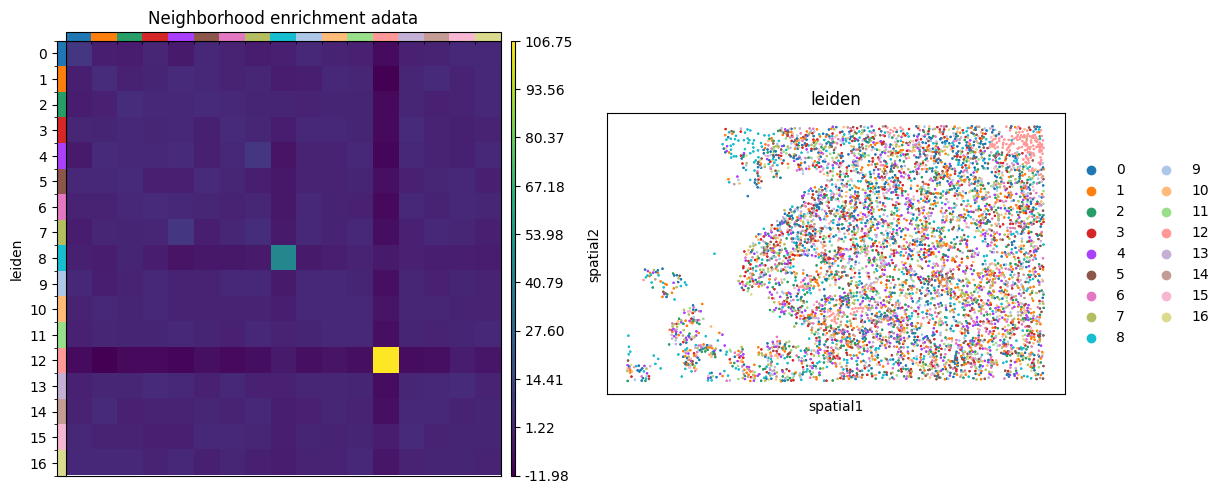

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color="leiden", shape=None, size=2, ax=ax[1])

# **Compute Moran’s I score**
This example shows how to compute the Moran’s I global spatial auto-correlation statistics.

The Moran’s I global spatial auto-correlation statistics evaluates whether features (i.e. genes) shows a pattern that is clustered, dispersed or random in the tissue are under consideration.

We can compute the Moran’s I score with squidpy.gr.spatial_autocorr and mode = ‘moran’. We first need to compute a spatial graph with squidpy.gr.spatial_neighbors. We will also subset the number of genes to evaluate.

In [ ]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/100 [00:00<?, ?/s]

,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
GJA5,0.342052,0.0,0.000057,0.0,0.009901,0.000068,0.0,0.0,0.024537
IGFBP3,0.311425,0.0,0.000057,0.0,0.009901,0.000067,0.0,0.0,0.024537
CXCL13,0.255999,0.0,0.000057,0.0,0.009901,0.000061,0.0,0.0,0.024537
ANPEP,0.217560,0.0,0.000057,0.0,0.009901,0.000064,0.0,0.0,0.024537
PLA2G7,0.204977,0.0,0.000057,0.0,0.009901,0.000069,0.0,0.0,0.024537
GPX2,0.199830,0.0,0.000057,0.0,0.009901,0.000051,0.0,0.0,0.024537
MYH11,0.192787,0.0,0.000057,0.0,0.009901,0.000050,0.0,0.0,0.024537
LTBP2,0.187088,0.0,0.000057,0.0,0.009901,0.000043,0.0,0.0,0.024537
DIRAS3,0.163331,0.0,0.000057,0.0,0.009901,0.000055,0.0,0.0,0.024537
AGR3,0.158846,0.0,0.000057,0.0,0.009901,0.000050,0.0,0.0,0.024537


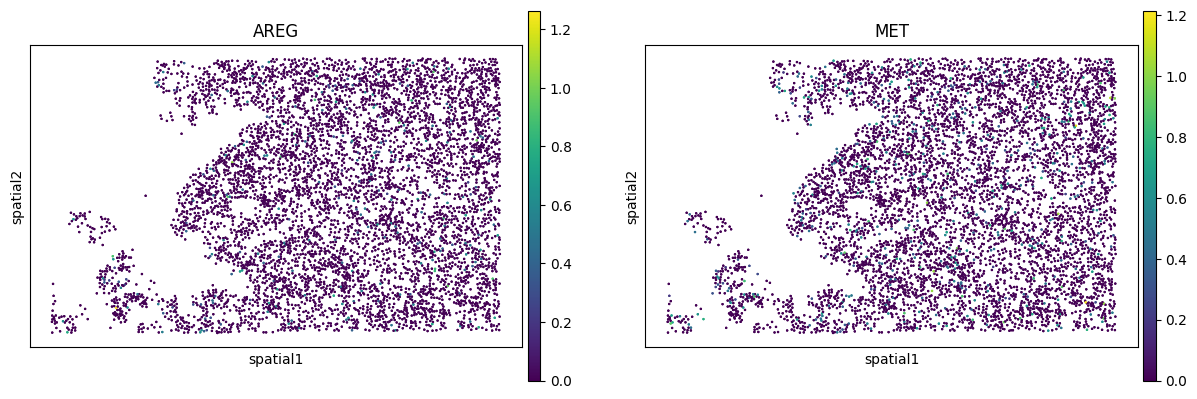

In [ ]:
sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=[
        "AREG",
        "MET",
    ],
    shape=None,
    size=2,
    img=False,
)

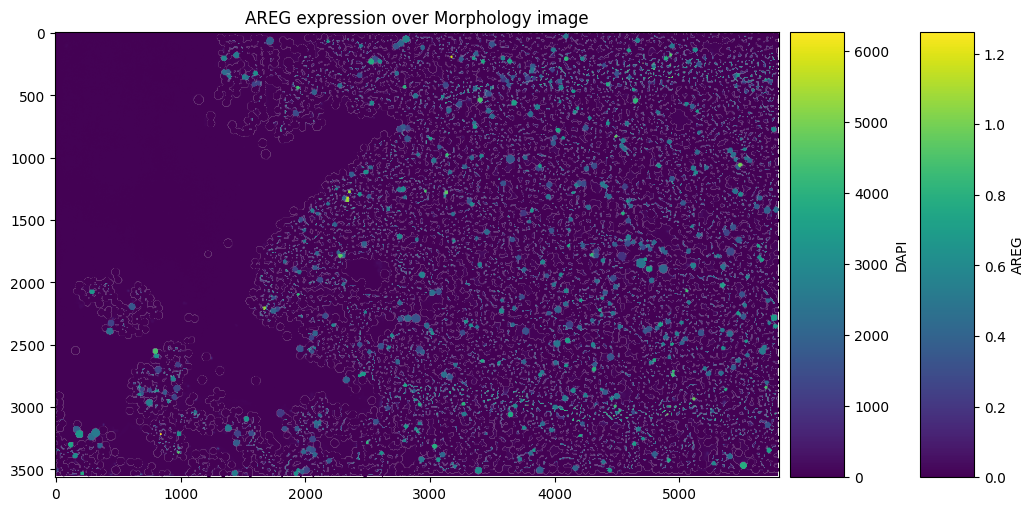

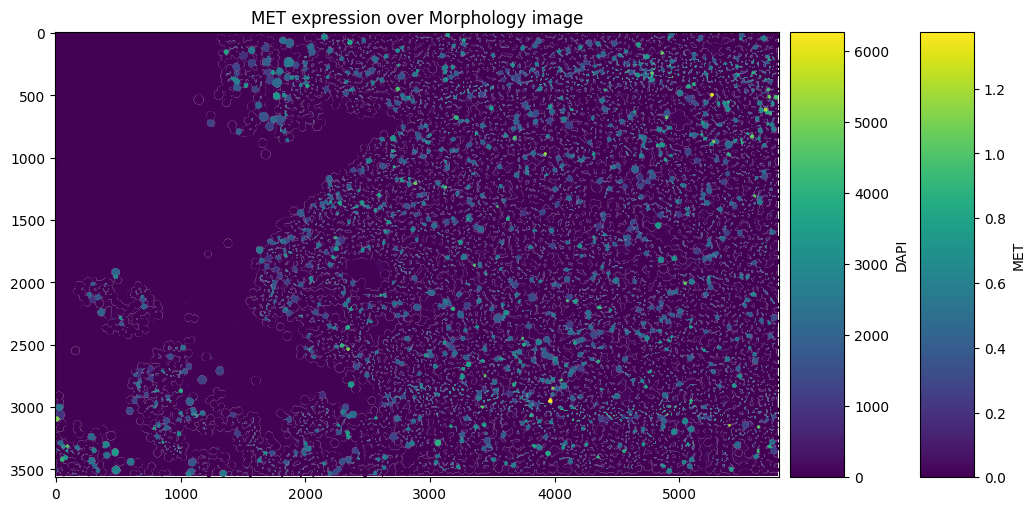

In [ ]:
import spatialdata_plot

gene_name = ["AREG", "MET"]
for name in gene_name:
    sdata.pl.render_images("morphology_focus").pl.render_shapes(
        "cell_circles",
        color=name,
        table_name="table",
        use_raw=False,
    ).pl.show(
        title=f"{name} expression over Morphology image",
        coordinate_systems="global",
        figsize=(10, 5),
    )